In [125]:
#.venv\Scripts\Activate.ps1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos los datos del archivo que tienes en tu carpeta
df = pd.read_csv('housingPracticeIA.csv')

# Vista previa de las primeras 5 filas
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [126]:
#Cuantas filas y columnas
df.shape

(20640, 10)

In [127]:
#Tipos de datos
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [128]:
#Numero de valores null
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [129]:
#Informacion general de los datos
print("Datos antes de limpiar")
df.info()

#Tratamos los valores nulos
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
print(df.isnull().sum())

Datos antes de limpiar
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dty

In [130]:
#Modulo de transformar datos, LabelEncoder sirve para pasar texto a numero
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

#Nueva columna con los nuevos valores
df['ocean_proximity_encoded'] = le.fit_transform(df['ocean_proximity'])

#Puedes modificar duplicates con duplicates(keep='first / False / last')        .sort_values('', ascending = False)
print(df[['ocean_proximity', 'ocean_proximity_encoded']].drop_duplicates().sort_values('ocean_proximity_encoded'))

     ocean_proximity  ocean_proximity_encoded
701        <1H OCEAN                        0
954           INLAND                        1
8314          ISLAND                        2
0           NEAR BAY                        3
1850      NEAR OCEAN                        4


In [131]:
#Datos principales
#std es desviacion estandar
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909,1.165843
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874,1.420662
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000,0.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,1.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000,1.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,4.000000


In [132]:
#Herramientas
from sklearn.model_selection import train_test_split 

#Modelos / algoritmos
from sklearn.linear_model import LinearRegression

#Preprocesadores 
from sklearn.preprocessing import StandardScaler

#Metricas de evaluacion

# 1. Seleccionamos las columnas numéricas como características (X)
# y el valor de la casa como nuestro objetivo a predecir (y)
X = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_encoded']]
y = df['median_house_value']

# 2. Dividimos los datos (80% entrenamiento, 20% pruebas)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalado
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Creamos la IA y la entrenamos con los datos de entrenamiento
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("IA entrenada")

IA entrenada


In [133]:
#Herramientas
from sklearn.metrics import mean_squared_error, r2_score

y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2: {r2:.2f}")
print(f"RMSE: ${rmse:,.0f}")

R2: 0.61
RMSE: $71,148


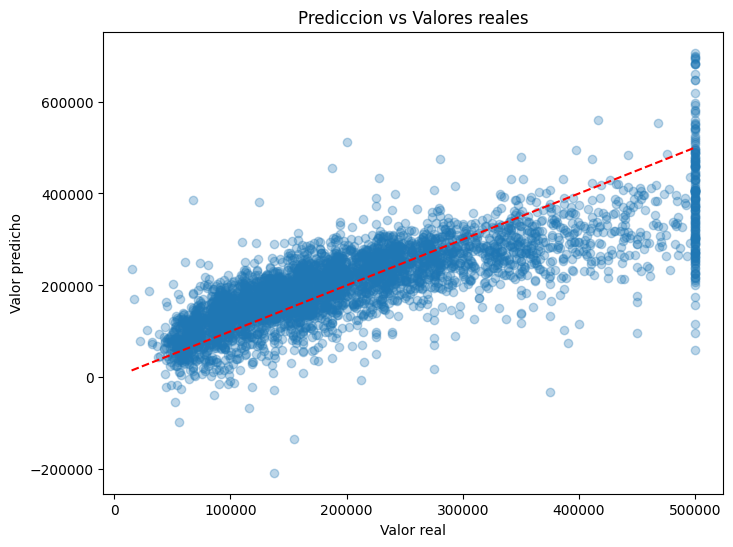

In [134]:
#Creo grafica con los puntos originales, y los que predije, la linea roja es la media
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Prediccion vs Valores reales")
plt.show()

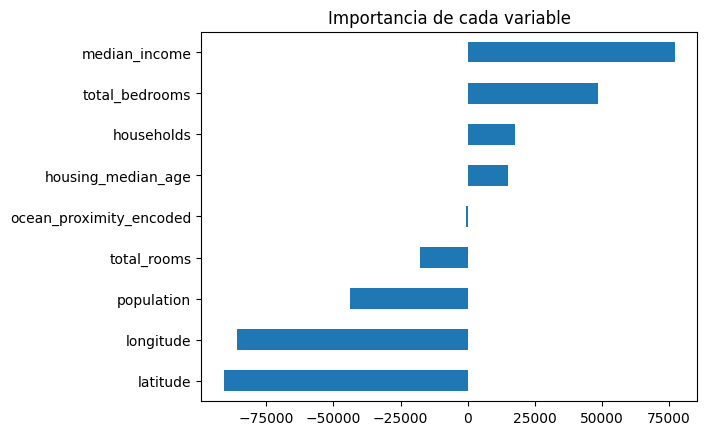

In [135]:
#Que tanta importancia tiene cada valor en la tabla
importancias = pd.Series(modelo.coef_, index=X.columns)
importancias.sort_values().plot(kind='barh')    #Alternativas: bar (vertical), line, pie
plt.title("Importancia de cada variable")
plt.show()

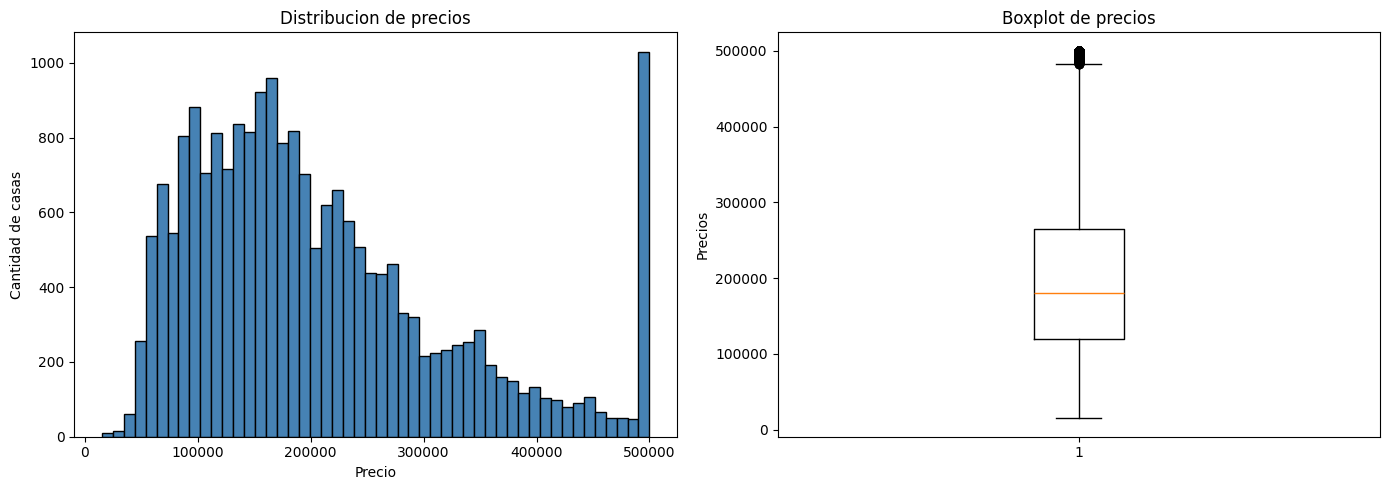

In [136]:
#Se crea el grid con subplot al ser mas de una, cuando trabajas con axes asignar cosas siempre lleva set_ antes
fig, axes = plt.subplots(1, 2, figsize=(14,5))  #Crea dos figuras y las guarda en axes[1] y axes[2] en este caso

#Histograma: Barras verticales pero la parte de abajo representa rangos de precios en lugar de etiquetas
axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title("Distribucion de precios")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Cantidad de casas")

#Boxplot: La linea roja de en medio es la media, los cuadros son porcentajes (75% y 25%) arriba y abajo de esta, lo ultimo se sale de los rangos
axes[1].boxplot(df['median_house_value'])
axes[1].set_title("Boxplot de precios")
axes[1].set_ylabel("Precios")

#Mostrar
plt.tight_layout()
plt.show()

In [137]:
#Libreria built-in
import pickle

#Se guarda el modelo (en disco)
#with abre un recurso y lo cierra automatico, open crea o abre un archivo, wb: write binary
with open('modelo_casas.pck', 'wb') as f:
    pickle.dump(modelo, f)  #Tomo el modelo ya declarado y lo guardo en f('modelo_casas.pck')

print("Modelo guardado")

#Con esto lo abriria
# with open('modelo_casas.pkl', 'rb') as f:    #rd: read binary
#    modelo = pickle.load(f)

Modelo guardado
